In [2]:
library(tidyverse)
library(dplyr)
library(cowplot)
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

── Attaching core tidyverse packages ───────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ─────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




# Load files ----------------------------------------------------------

In [3]:
# Read file
fp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/saliva/tp1_nulliparous/2025-12-09_no_min_abundance_fp_tp1_nulliparous_saliva.csv", header = TRUE)
sp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/saliva/tp1_nulliparous/2025-12-09_no_min_abundance_fp_tp1_nulliparous_saliva.csv", header = TRUE)
combined <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/saliva/tp1_nulliparous/2025-12-09_no_min_abundance_combined_nulliparous_fp_sp_tp1_saliva.csv", header = TRUE)

In [4]:
#summary(combined)
combined$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "Second pregnancy" "Second pregnancy" "Second pregnancy"
[13] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[17] "Second pregnancy" "Second pregnancy"

In [5]:
head(fp_tp1)
dim(fp_tp1)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<chr>,<int>,<chr>,<lgl>,<lgl>,<int>,<chr>
1,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,S50f102c,NA,0,0,0,2018-08-05,P50f102c,0,32,3,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
3,S735d77f,NA,0,0,0,2018-08-24,P735d77f,0,25,2,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
4,S9026714,NA,0,0,2,2019-01-02,P7ece52e,0,25,2,⋯,NA,NA,NA,NA,41,Induction,NA,NA,0,First pregnancy
5,Se5be4e8,NA,0,0,0,2018-07-03,Pbbb08bd,0,33,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
6,Sc9a3575,NA,0,0,0,2018-01-31,Pc9a3575,0,30,3,⋯,24,0,0,IUFD Jag fick havandeskapsförgiftning i v.22 och var tvungen att bli igångsatt. Flickan föddes i v. 24 +0 och överlevde tyvärr inte.,24,Induction,NA,NA,1,First pregnancy


[1]   9 566

In [6]:
head(sp_tp1)
dim(sp_tp1)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<chr>,<int>,<chr>,<lgl>,<lgl>,<int>,<chr>
1,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,S50f102c,NA,0,0,0,2018-08-05,P50f102c,0,32,3,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
3,S735d77f,NA,0,0,0,2018-08-24,P735d77f,0,25,2,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
4,S9026714,NA,0,0,2,2019-01-02,P7ece52e,0,25,2,⋯,NA,NA,NA,NA,41,Induction,NA,NA,0,First pregnancy
5,Se5be4e8,NA,0,0,0,2018-07-03,Pbbb08bd,0,33,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
6,Sc9a3575,NA,0,0,0,2018-01-31,Pc9a3575,0,30,3,⋯,24,0,0,IUFD Jag fick havandeskapsförgiftning i v.22 och var tvungen att bli igångsatt. Flickan föddes i v. 24 +0 och överlevde tyvärr inte.,24,Induction,NA,NA,1,First pregnancy


[1]   9 566

In [7]:
head(combined)
dim(combined)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,S50f102c,NA,0,0,0,2018-08-05,P50f102c,0,32,3,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
3,S735d77f,NA,0,0,0,2018-08-24,P735d77f,0,25,2,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
4,S9026714,NA,0,0,2,2019-01-02,P7ece52e,0,25,2,⋯,NA,NA,NA,NA,41,Induction,NA,NA,0,First pregnancy
5,Se5be4e8,NA,0,0,0,2018-07-03,Pbbb08bd,0,33,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
6,Sc9a3575,NA,0,0,0,2018-01-31,Pc9a3575,0,30,3,⋯,24,0,0,IUFD Jag fick havandeskapsförgiftning i v.22 och var tvungen att bli igångsatt. Flickan föddes i v. 24 +0 och överlevde tyvärr inte.,24,Induction,NA,NA,1,First pregnancy


[1]  18 566

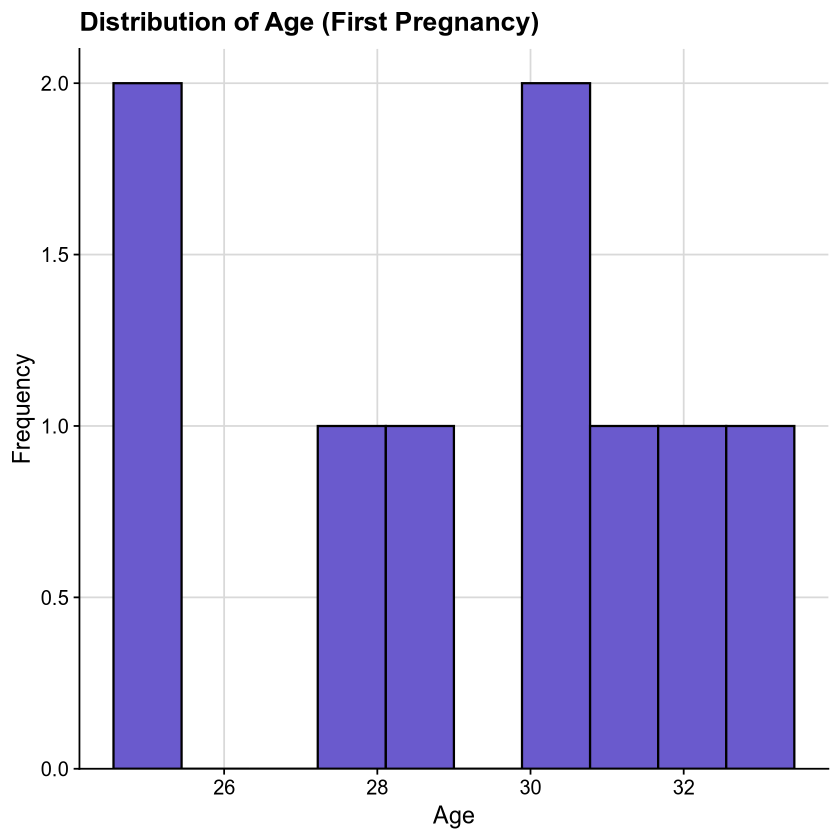

In [8]:
#===============================================================================
# Histogram for the age distribution (remove NA values)
# First Pregnancy 
fp_tp1_plot <- fp_tp1 |> 
  ggplot(aes(x = age_checked)) + 
  geom_histogram(bins = 10, fill = "slateblue", color = "black", na.rm = TRUE) +
  labs(
    title = "Distribution of Age (First Pregnancy)",
    x = "Age",
    y = "Frequency"
  ) +
  scale_y_continuous(
    # don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  )
  fp_tp1_plot + theme_half_open() +
  background_grid()

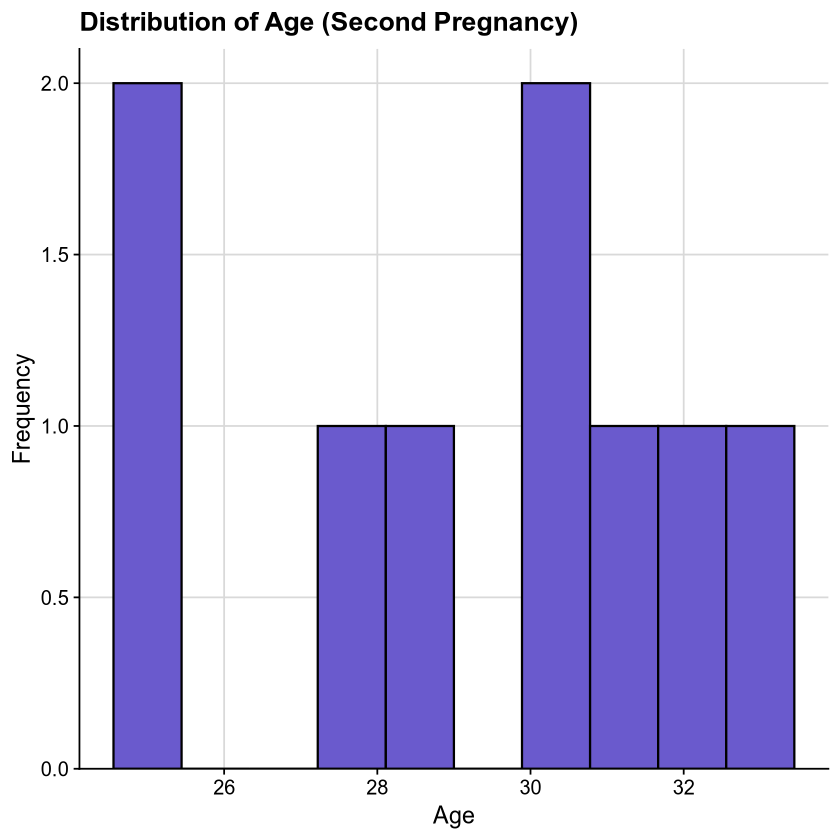

In [9]:
  
#Second Pregnancy
sp_tp1_plot <- sp_tp1 |> 
  ggplot(aes(x = age_checked)) +
  geom_histogram(bins = 10, fill = "slateblue", color = "black", na.rm = TRUE) +
  labs(
    title = "Distribution of Age (Second Pregnancy)",
    x = "Age",
    y = "Frequency"
  ) +
  scale_y_continuous(
    # don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  )
sp_tp1_plot + theme_half_open() +
  background_grid()

In [10]:
# Checking for NA ages
fp_tp1 |> filter(is.na(fp_tp1$age_checked)) |> pull(Q1_Personnummer)
sp_tp1 |> filter(is.na(fp_tp1$age_checked)) |> pull(Q1_Personnummer)

character(0)

character(0)

In [11]:
# Perform Shapiro-Wilk test for First Pregnancy --> we can trust the shapiro test since our sample size isnt so large
shapiro_first <- shapiro.test(fp_tp1$age_checked)
shapiro_first


	Shapiro-Wilk normality test

data:  fp_tp1$age_checked
W = 0.92537, p-value = 0.4385


In [12]:
# Perform Shapiro-Wilk test for Second Pregnancy
shapiro_second <- shapiro.test(sp_tp1$age_checked)
shapiro_second


	Shapiro-Wilk normality test

data:  sp_tp1$age_checked
W = 0.92537, p-value = 0.4385


# Age_checked========================================================================================================================================

In [13]:
Age_summary_stats <- combined|>
  group_by(Group) |>
  summarise(
    mean_age = mean(age_checked, na.rm = TRUE),
    sd_age = sd(age_checked, na.rm = TRUE),
    min_age = min(age_checked, na.rm = TRUE),
    max_age = max(age_checked, na.rm = TRUE)
  )
print(Age_summary_stats)

# A tibble: 2 × 5
  Group              mean_age sd_age min_age max_age
  <chr>                 <dbl>  <dbl>   <int>   <int>
1 "First pregnancy "     29.2   2.82      25      33
2 "Second pregnancy"     30.9   2.89      26      34


In [14]:
# Check NA
combined |> filter(is.na(combined$age_checked)) |> group_by(Group) |> pull(Q1_Personnummer)

character(0)

# BMI_prior========================================================================================================================================

In [15]:
combined$BMI_prior
BMI_summary_stat <- combined |>
  group_by(Group)|> 
  summarise(
    mean_bmi = mean(BMI_prior, na.rm = TRUE),
    sd_bmi = sd(BMI_prior, na.rm = TRUE),
    min_bmi = min(BMI_prior, na.rm = TRUE),
    max_bmi = max(BMI_prior, na.rm = TRUE)
  )
print(BMI_summary_stat)

[1] 21 19 24 27 21 24 23 23 23 23 19 33 26 21 27 23 23 21

# A tibble: 2 × 5
  Group              mean_bmi sd_bmi min_bmi max_bmi
  <chr>                 <dbl>  <dbl>   <int>   <int>
1 "First pregnancy "     22.8   2.28      19      27
2 "Second pregnancy"     24     4.18      19      33


# BMI categories -------------------------------------------------------------

In [16]:
meta_BMI_update <- combined %>%
 mutate(
  BMI_group_prior = case_when(
   BMI_prior < 18.5 ~ "Underweight",
   BMI_prior >= 18.5 & BMI_prior <= 24.9 ~ "Normalweight",
   BMI_prior >= 25 & BMI_prior <= 29.9 ~ "Overweight",
   BMI_prior >= 30 ~ "Obese",
   TRUE ~ NA_character_  
 ))

head(meta_BMI_update)
dim(meta_BMI_update)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group,BMI_group_prior
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy,Normalweight
2,S50f102c,NA,0,0,0,2018-08-05,P50f102c,0,32,3,⋯,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy,Normalweight
3,S735d77f,NA,0,0,0,2018-08-24,P735d77f,0,25,2,⋯,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy,Normalweight
4,S9026714,NA,0,0,2,2019-01-02,P7ece52e,0,25,2,⋯,NA,NA,NA,41,Induction,NA,NA,0,First pregnancy,Overweight
5,Se5be4e8,NA,0,0,0,2018-07-03,Pbbb08bd,0,33,3,⋯,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy,Normalweight
6,Sc9a3575,NA,0,0,0,2018-01-31,Pc9a3575,0,30,3,⋯,0,0,IUFD Jag fick havandeskapsförgiftning i v.22 och var tvungen att bli igångsatt. Flickan föddes i v. 24 +0 och överlevde tyvärr inte.,24,Induction,NA,NA,1,First pregnancy,Normalweight


[1]  18 567

In [17]:
# BMI_groups
grep("BMI", names(meta_BMI_update), value = TRUE)
meta_BMI_update$BMI_group_prior
# check type of data
class(meta_BMI_update$BMI_group_prior)

[1] "BMI_prior"        "BMI_3_groups"     "BMI_now_3_groups" "BMI_group_prior"

[1] "Normalweight" "Normalweight" "Normalweight" "Overweight"   "Normalweight"
 [6] "Normalweight" "Normalweight" "Normalweight" "Normalweight" "Normalweight"
[11] "Normalweight" "Obese"        "Overweight"   "Normalweight" "Overweight"  
[16] "Normalweight" "Normalweight" "Normalweight"

[1] "character"

In [18]:
# Count total in both groups
total_counts_bmi <- table(meta_BMI_update$Group)
print(total_counts_bmi)


First pregnancy  Second pregnancy 
               9                9 


In [19]:
# Calculate the count and percentage for each BMI_3_groups within each group
BMI_3_groups_summary <- meta_BMI_update |>
  group_by(Group, BMI_group_prior) |>         
  summarise(
    count = n(),
    
    .groups = 'drop'  # This argument drops the grouping after summarising                    
  ) |>
  group_by(Group) |> # Regroup by 'group' to calculate percentage
  mutate(
    percentage = (count / sum(count)) * 100  
  )
print(BMI_3_groups_summary)

# A tibble: 5 × 4
# Groups:   Group [2]
  Group              BMI_group_prior count percentage
  <chr>              <chr>           <int>      <dbl>
1 "First pregnancy " Normalweight        8       88.9
2 "First pregnancy " Overweight          1       11.1
3 "Second pregnancy" Normalweight        6       66.7
4 "Second pregnancy" Obese               1       11.1
5 "Second pregnancy" Overweight          2       22.2


# Excess weight========================================================================================================================================

In [20]:
grep("excess",names(combined), value = TRUE )
class(combined$excess_weight)
table(combined$excess_weight)

combined$excess_weight <- as.factor(combined$excess_weight)
total_counts_excess_weight <- table(combined$Group)

[1] "excess_weight"

[1] "character"


 No Yes 
 11   6 

In [21]:
# Generate a table
summary_excess_weight <- combined |>
  group_by(Group, excess_weight) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count / sum(count)) * 100
  )
print(summary_excess_weight)

# A tibble: 5 × 4
# Groups:   Group [2]
  Group              excess_weight count percentage
  <chr>              <fct>         <int>      <dbl>
1 "First pregnancy " No                7       77.8
2 "First pregnancy " Yes               2       22.2
3 "Second pregnancy" No                4       44.4
4 "Second pregnancy" Yes               4       44.4
5 "Second pregnancy" NA                1       11.1


# Gestational diabetes========================================================================================================================================

In [22]:
grep("diabetes", names(combined), value = TRUE)
table(combined$Q1_X73.1_Pregnancy_problems_gestational_diabetes)

[1] "Q1_X73.1_Pregnancy_problems_gestational_diabetes"
[2] "Q1_prior_diabetes_medication"                    
[3] "Q1_during_diabetes_medication"                   
[4] "Q2_X13.1.Pregproblem_gestational_diabetes"       
[5] "Q2_diabetes_medication"                          
[6] "Q3_X41_Pregproblem_gestational_diabetes"         
[7] "Q3_diabetes_medication"

< table of extent 0 >

In [23]:
class(combined$Q1_X73.1_Pregnancy_problems_gestational_diabetes)
combined$Q1_X73.1_Pregnancy_problems_gestational_diabetes <- as.factor(combined$Q1_X73.1_Pregnancy_problems_gestational_diabetes)

[1] "logical"

In [24]:
summary_diabetes <- combined |>
  group_by(Group, Q1_X73.1_Pregnancy_problems_gestational_diabetes) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count / sum(count)) * 100
  )
print(summary_diabetes)

# A tibble: 2 × 4
# Groups:   Group [2]
  Group              Q1_X73.1_Pregnancy_problems_gestational_…¹ count percentage
  <chr>              <fct>                                      <int>      <dbl>
1 "First pregnancy " NA                                             9        100
2 "Second pregnancy" NA                                             9        100
# ℹ abbreviated name: ¹​Q1_X73.1_Pregnancy_problems_gestational_diabetes


# Depression========================================================================================================================================

In [25]:
grep("depression", names(combined), value= TRUE)
grep("Depression", names(combined), value= TRUE)
combined$Depression_score_sum_Q1
class(combined$Depression_score_sum_Q1)

[1] "Q1_X73.7_Pregnancy_problems_depression"
[2] "Q2_X13.7.Pregproblem_depression"       
[3] "Q3_X41_Pregproblem_depression"

[1] "Depression_score_sum_Q1" "Depression_score_sum_Q2"
[3] "Depression_score_sum_Q3"

[1]  3  1  6 18  6  7 13  2  2 15  2  2  7  4 12  8  6  3

[1] "integer"

In [26]:
# Convert to categories
depression_category <- ifelse(combined$Depression_score_sum_Q1 >= 0 & combined$Depression_score_sum_Q1 < 13,  "no depression", 
                              ifelse(combined$Depression_score_sum_Q1 >= 13 & combined$Depression_score_sum_Q1 <= 30, "depression", NA))
depression_category
sum(is.na(depression_category))

[1] "no depression" "no depression" "no depression" "depression"   
 [5] "no depression" "no depression" "depression"    "no depression"
 [9] "no depression" "depression"    "no depression" "no depression"
[13] "no depression" "no depression" "no depression" "no depression"
[17] "no depression" "no depression"

[1] 0

In [27]:
combined$Q1_Depression_category <- depression_category
table(combined$Q1_Depression_category)


   depression no depression 
            3            15 

In [28]:
Q1_summary_depression <- combined |>
  group_by(Group, Q1_Depression_category) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count / sum(count)) * 100
  )
print(Q1_summary_depression)

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              Q1_Depression_category count percentage
  <chr>              <chr>                  <int>      <dbl>
1 "First pregnancy " depression                 2       22.2
2 "First pregnancy " no depression              7       77.8
3 "Second pregnancy" depression                 1       11.1
4 "Second pregnancy" no depression              8       88.9


# Stress================================================================================================================================================================================================================

In [29]:
combined$high_stress_Q1
table(combined$high_stress_Q1)

[1] 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0


 0  1 
14  4 

In [30]:
summary_stress <- combined |>
  group_by(Group, high_stress_Q1) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count / sum(count)) * 100
  )
print(summary_stress)

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              high_stress_Q1 count percentage
  <chr>                       <int> <int>      <dbl>
1 "First pregnancy "              0     7       77.8
2 "First pregnancy "              1     2       22.2
3 "Second pregnancy"              0     7       77.8
4 "Second pregnancy"              1     2       22.2


# Smoking===============================================================================================================================================================================================================

In [31]:
grep("smok", names(combined), value = TRUE)
grep("Smok", names(combined), value = TRUE)

[1] "Q1_X55_Year_stopped_smoking"       "Q1_X57_Which_other_smoking_habits"
[3] "smoking"

[1] "Q1_Smoking_checked"                  
[2] "Q2_X25_Smoking_snus_now"             
[3] "Q3_X35_Smoking_snus_end_of_pregnancy"

In [32]:
combined$Q1_Smoking_checked

[1] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
 [3] "Rökt tidigare"            "Rökt tidigare"           
 [5] "Rökt tidigare"            "Nej, jag har aldrig rökt"
 [7] "Rökt tidigare"            "Nej, jag har aldrig rökt"
 [9] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[11] "Nej, jag har aldrig rökt" "Rökt tidigare"           
[13] "Rökt tidigare"            "Rökt tidigare"           
[15] "Nej, jag har aldrig rökt" "Rökt tidigare"           
[17] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"

In [33]:
# Convert Q1_Smoking_ to categorieschecked
smoking_category <- ifelse(combined$Q1_Smoking_checked == "Nej, jag har aldrig rökt", 0, 
                           ifelse(combined$Q1_Smoking_checked == "Rökt tidigare", 0,
                              ifelse(combined$Q1_Smoking_checked == "Feströkare", 1, NA)))
table(smoking_category)
# Check for NA
sum(is.na(smoking_category))

smoking_category
 0 
18 

[1] 0

In [34]:
# Create new column with smoking category
combined$smoking_category_Q1 <- smoking_category
combined$smoking_category_Q1

summary_smoking <- combined |>
  group_by(Group, smoking_category_Q1) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count / sum(count)) * 100
  ) 
print(summary_smoking)

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

# A tibble: 2 × 4
# Groups:   Group [2]
  Group              smoking_category_Q1 count percentage
  <chr>                            <dbl> <int>      <dbl>
1 "First pregnancy "                   0     9        100
2 "Second pregnancy"                   0     9        100


# Alcohol===============================================================================================================================================================================================================

In [35]:
grep("Alcohol", names(combined), value = TRUE)
combined$Q1_X64_Alcohol_during_pregnancy
class(combined$Q1_X64_Alcohol_during_pregnancy)

[1] "Q1_X62_Alcohol_3_months_before_pregnancy"    
[2] "Q1_X64_Alcohol_during_pregnancy"             
[3] "Q1_X62_Alcohol_3_months_before_pregnancy_cat"
[4] "Q1_X64_Alcohol_during_pregnancy_cat"

[1] 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0

[1] "integer"

In [36]:
summary_alcohol <- combined |>
  group_by(Group, Q1_X64_Alcohol_during_pregnancy) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/ sum(count)) * 100
  )
print(summary_alcohol)

# A tibble: 3 × 4
# Groups:   Group [2]
  Group              Q1_X64_Alcohol_during_pregnancy count percentage
  <chr>                                        <int> <int>      <dbl>
1 "First pregnancy "                               0     8       88.9
2 "First pregnancy "                               1     1       11.1
3 "Second pregnancy"                               0     9      100  


# Antibiotic================================================================================================================================================================================================================================================================================

In [37]:
combined$Q1_X43.Antibiotics_last_3_months

Q1_summary_antibiotics <- combined %>%
  group_by(Group) %>%
  summarise(
    yes_count = sum(Q1_X43.Antibiotics_last_3_months == 1, na.rm = TRUE),  # counts only "yes"
    total = n(), # Total in each group
    percent_yes = (yes_count / total) * 100   # Percentage
  )

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [38]:
Q1_summary_antibiotics
# Check NA - do I need this in this case?
combined |> 
  filter(is.na(combined$Q1_X43.Antibiotics_last_3_months)) |> 
  group_by(Group) |> pull(Q1_Personnummer)

Group,yes_count,total,percent_yes
<chr>,<int>,<int>,<dbl>
First pregnancy,0,9,0
Second pregnancy,0,9,0


character(0)

# Diet================================================================================================================================================================================================================================================================================

In [39]:
combined$Q1_dietscore
combined$Q1_healthydiet 
combined$Q1_dailyfiber 

[1] 1 1 3 2 2 0 0 1 2 4 0 3 2 1 1 1 1 2

[1] 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1

[1] 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1

In [40]:
# combined$Q1_healthydiet --> yes if health score less than 3
summary_diet <- combined |>
  group_by(Group, Q1_healthydiet) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/sum(count)) * 100
  )
print(summary_diet)

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              Q1_healthydiet count percentage
  <chr>                       <int> <int>      <dbl>
1 "First pregnancy "              0     1       11.1
2 "First pregnancy "              1     8       88.9
3 "Second pregnancy"              0     2       22.2
4 "Second pregnancy"              1     7       77.8


# Daily fiber================================================================================================================================================================================================================================================================================

In [41]:
combined$Q1_dailyfiber
summary_fiber <-  combined |>
  group_by(Group, Q1_dailyfiber) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/sum(count)) * 100
  )
print(summary_fiber)

[1] 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1

# A tibble: 3 × 4
# Groups:   Group [2]
  Group              Q1_dailyfiber count percentage
  <chr>                      <int> <int>      <dbl>
1 "First pregnancy "             1     9      100  
2 "Second pregnancy"             0     1       11.1
3 "Second pregnancy"             1     8       88.9


# PCOS========================================================================================================================================

In [42]:
combined$Q1_X31_Diagnosed_PCOS

summary_PCOS <- combined |>
  group_by(Group, Q1_X31_Diagnosed_PCOS) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/ sum(count)) * 100
  )
print(summary_PCOS)

[1] "Nej"      "Ja"       "Nej"      "Nej"      "Nej"      "Nej"     
 [7] "Nej"      "Ja"       "Vet inte" "Nej"      "Ja"       "Nej"     
[13] "Nej"      "Nej"      "Nej"      "Nej"      "Ja"       "Nej"

# A tibble: 5 × 4
# Groups:   Group [2]
  Group              Q1_X31_Diagnosed_PCOS count percentage
  <chr>              <chr>                 <int>      <dbl>
1 "First pregnancy " Ja                        2       22.2
2 "First pregnancy " Nej                       6       66.7
3 "First pregnancy " Vet inte                  1       11.1
4 "Second pregnancy" Ja                        2       22.2
5 "Second pregnancy" Nej                       7       77.8


# Diabetes========================================================================================================================================

In [43]:
grep("diabetes", names(combined), value = TRUE)
grep("Diabetes", names(combined), value = TRUE)

[1] "Q1_X73.1_Pregnancy_problems_gestational_diabetes"
[2] "Q1_prior_diabetes_medication"                    
[3] "Q1_during_diabetes_medication"                   
[4] "Q2_X13.1.Pregproblem_gestational_diabetes"       
[5] "Q2_diabetes_medication"                          
[6] "Q3_X41_Pregproblem_gestational_diabetes"         
[7] "Q3_diabetes_medication"

[1] "Gest_Diabetes"

# Preeclampsia============================================================================

In [44]:
grep("preeclampsia", names(combined), value = TRUE)
grep("Preeclampsia", names(combined), value = TRUE)

[1] "Q1_X73.5_Pregnancy_problems_preeclampsia"
[2] "Q2_X13.5.Pregproblem_preeclampsia"       
[3] "preeclampsia_epi_analysis"

character(0)

In [45]:
class(combined$Q1_X73.5_Pregnancy_problems_preeclampsia)
combined$Q1_X73.5_Pregnancy_problems_preeclampsia
combined$Q1_X73.5_Pregnancy_problems_preeclampsia <- as.factor(combined$Q1_X73.5_Pregnancy_problems_preeclampsia)
class(combined$Q1_X73.5_Pregnancy_problems_preeclampsia)
combined$Q1_X73.5_Pregnancy_problems_preeclampsia

[1] "logical"

[1] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA

[1] "factor"

[1] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[16] <NA> <NA> <NA>
Levels:

In [46]:
summary_preeclampsia <- combined |>
  group_by(Group, Q1_X73.5_Pregnancy_problems_preeclampsia) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/ sum(count)) * 100
  )
print(summary_preeclampsia)

# A tibble: 2 × 4
# Groups:   Group [2]
  Group              Q1_X73.5_Pregnancy_problems_preeclampsia count percentage
  <chr>              <fct>                                    <int>      <dbl>
1 "First pregnancy " NA                                           9        100
2 "Second pregnancy" NA                                           9        100


# Hypertension====================================================================================

In [47]:
grep("pressure", names(combined), value = TRUE)


[1] "Q1_X66.2_prior_treatment_high_bloodpressure"   
 [2] "Q1_X73.4_Pregnancy_problems_high_bloodpressure"
 [3] "Q1_X75_prior_bloodpressure_medication"         
 [4] "Q1_X77_during_bloodpressure_medication"        
 [5] "Q1_prior_bloodpressure"                        
 [6] "Q1_during_bloodpressure"                       
 [7] "Q2_X13.4.Pregproblem_high_bloodpressure"       
 [8] "Q2_X15_during_bloodpressure_medication"        
 [9] "Q2_bloodpressure"                              
[10] "Q3_X42_during_bloodpressure_medication"        
[11] "Q3_bloodpressure"

In [48]:
combined$Q1_X73.4_Pregnancy_problems_high_bloodpressure

[1] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA

In [49]:
combined$Q1_prior_bloodpressure

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [50]:
combined$Q1_during_bloodpressure

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [51]:
combined$Q2_X13.4.Pregproblem_high_bloodpressure

[1] NA    NA    NA    NA    "Nej" NA    NA    NA    NA    NA    NA    NA   
[13] NA    NA    "Ja"  NA    NA    NA

In [55]:
summary_bp <- combined |>
  group_by(Group, Q1_during_bloodpressure) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/ sum(count)) * 100
  )
print(summary_bp)

# A tibble: 2 × 4
# Groups:   Group [2]
  Group              Q1_during_bloodpressure count percentage
  <chr>                                <int> <int>      <dbl>
1 "First pregnancy "                       0     9        100
2 "Second pregnancy"                       0     9        100


# Dentist -------------------------------------------------------------

In [53]:
combined$Q1_X50_Dentist_3_months_before_pregnancy |> table()


 0  1 
14  4 

In [54]:
combined$Q1_X50_Dentist_3_months_before_pregnancy

summary_dentist <- combined |>
  group_by(Group, Q1_X50_Dentist_3_months_before_pregnancy) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/ sum(count)) * 100
  )
print(summary_dentist)

[1] 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              Q1_X50_Dentist_3_months_before_pregnancy count percentage
  <chr>                                                 <int> <int>      <dbl>
1 "First pregnancy "                                        0     8       88.9
2 "First pregnancy "                                        1     1       11.1
3 "Second pregnancy"                                        0     6       66.7
4 "Second pregnancy"                                        1     3       33.3
